**ASSIGNMENT 4**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Dataset 2.csv to Dataset 2 (2).csv


In [ ]:
#1. Load the dataset and display the first five records.
import pandas as pd
df = pd.read_csv('Dataset 2.csv')
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [ ]:
#2. Number of rows and columns
print(df.shape)

(750, 10)


In [ ]:
#3. Display all column names
print(df.columns.tolist())

['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend', 'SubscriptionRenewed']


In [ ]:
#4. Numerical and categorical features
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical:", numerical)
print("Categorical:", categorical)

Numerical: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']
Categorical: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


In [ ]:
#5. Missing values
print(df.isnull().sum())
# To check if ANY missing values exist:
print("Has missing values:", df.isnull().values.any())

UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64
Has missing values: False


In [ ]:
#6. Average age of users
avg_age = df['Age'].mean()
print("Average age: ",avg_age)

Average age:  41.824


In [ ]:
#7. Average watch hours per week
avg_watch = df['WatchHoursPerWeek'].mean()
print("Average Watch Hours Per Week: ", avg_watch)

Average Watch Hours Per Week:  14.236


In [ ]:
#8. Average monthly spending
avg_spend = df['MonthlySpend'].mean()
print("Average Monthly Spending: ", avg_spend)

Average Monthly Spending:  689.9053333333334


In [ ]:
#9. Users in each subscription category
sub_counts = df['SubscriptionType'].value_counts()
print("Users per Subscription Category: ")
print(sub_counts)

Users per Subscription Category: 
SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


In [ ]:
#10. Percentage of users who renewed their subscriptions
renewal_pct = df['SubscriptionRenewed'].value_counts(normalize=True) * 100
print("Renewal Percentage: ")
print(renewal_pct)

Renewal Percentage: 
SubscriptionRenewed
No     53.733333
Yes    46.266667
Name: proportion, dtype: float64


In [ ]:
#11. Convert categorical features into numerical form
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])
df['SubscriptionType_enc'] = le.fit_transform(df['SubscriptionType'])
df['FavoriteGenre_enc'] = le.fit_transform(df['FavoriteGenre'])
df['SubscriptionRenewed_enc'] = le.fit_transform(df['SubscriptionRenewed'])

print(df[['Gender','Gender_enc','SubscriptionType','SubscriptionType_enc',
          'FavoriteGenre','FavoriteGenre_enc','SubscriptionRenewed','SubscriptionRenewed_enc']].head())

   Gender  Gender_enc SubscriptionType  SubscriptionType_enc FavoriteGenre  \
0  Female           0            Basic                     0        Comedy   
1    Male           1            Basic                     0         Drama   
2    Male           1            Basic                     0        Comedy   
3  Female           0          Premium                     1         Drama   
4  Female           0          Premium                     1        Sci-Fi   

   FavoriteGenre_enc SubscriptionRenewed  SubscriptionRenewed_enc  
0                  1                  No                        0  
1                  2                 Yes                        1  
2                  1                  No                        0  
3                  2                 Yes                        1  
4                  5                 Yes                        1  


In [ ]:
#12. Define feature set (X) and target variable (y)
X = df[['Age', 'Gender_enc', 'SubscriptionType_enc', 'WatchHoursPerWeek',
        'DevicesUsed', 'FavoriteGenre_enc', 'AdClicks']]
y = df['SubscriptionRenewed_enc']
print("Feature set shape: ", X.shape)
print("Target variable shape: ", y.shape)

Feature set shape:  (750, 7)
Target variable shape:  (750,)


In [ ]:
#13. Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size: ", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size:  (600, 7)
Testing set size:  (150, 7)


In [ ]:
#14. Train a Decision Tree model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision tree model trained successfully")

Decision tree model trained successfully


In [ ]:
#15. Evaluate the model using accuracy
from sklearn.metrics import accuracy_score

y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy: ", dt_accuracy)

Decision Tree Accuracy:  0.5533333333333333


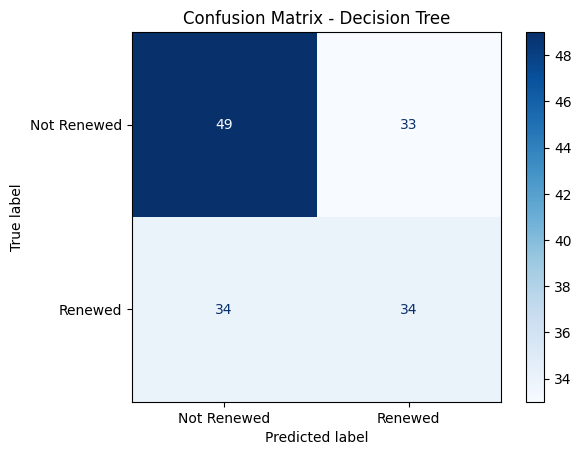

Confusion Matrix: 
[[49 33]
 [34 34]]
True Negatives (correctly predicted Not Renewed):  49
False Positives (wrongly predicted Renewed):  33
False Negatives (wrongly predicted Not Renewed):  34
True Positives (correctly predicted Renewed):  34


In [ ]:
# Q16. Generate and interpret the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Renewed', 'Renewed'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()
print("Confusion Matrix: ")
print(cm)
print("True Negatives (correctly predicted Not Renewed): ", cm[0][0])
print("False Positives (wrongly predicted Renewed): ", cm[0][1])
print("False Negatives (wrongly predicted Not Renewed): ", cm[1][0])
print("True Positives (correctly predicted Renewed): ", cm[1][1])

In [ ]:
#17. Train a KNN classifier with K=5
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy (K=5): ", knn_accuracy)

KNN Accuracy (K=5):  0.5866666666666667


In [ ]:
#18. Compare accuracy of KNN vs Decision Tree
print("Decision Tree Accuracy: ", dt_accuracy)
print("KNN Accuracy:           ", knn_accuracy)
if dt_accuracy > knn_accuracy:
    print("Decision Tree performs better than KNN")
elif knn_accuracy > dt_accuracy:
    print("KNN performs better than Decision Tree")
else:
    print("Both models have equal accuracy")

Decision Tree Accuracy:  0.5533333333333333
KNN Accuracy:            0.5866666666666667
KNN performs better than Decision Tree


In [ ]:
#19. Train a Linear Regression model to predict monthly spending
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X_reg = df[['Age', 'Gender_enc', 'SubscriptionType_enc', 'WatchHoursPerWeek',
            'DevicesUsed', 'FavoriteGenre_enc', 'AdClicks']]
y_reg = df['MonthlySpend']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)
y_pred_lr = lr_model.predict(X_test_r)

print("R2 Score: ", r2_score(y_test_r, y_pred_lr))
print("Mean Squared Error: ", mean_squared_error(y_test_r, y_pred_lr))

R2 Score:  0.9666019015911183
Mean Squared Error:  4835.490092736498


In [ ]:
#20. Predict monthly spending for a new user
new_user = pd.DataFrame([[30, 0, 1, 15, 3, 1, 20]],
                        columns=['Age', 'Gender_enc', 'SubscriptionType_enc',
                                 'WatchHoursPerWeek', 'DevicesUsed',
                                 'FavoriteGenre_enc', 'AdClicks'])
predicted_spend = lr_model.predict(new_user)
print("Predicted Monthly Spending for new user: ", predicted_spend[0])
print("Interpretation: Based on the user profile (Age=30, Female, Premium plan,")
print("15 watch hrs/week, 3 devices, Comedy genre, 20 ad clicks),")
print("the model predicts a monthly spending of approximately Rs.", round(predicted_spend[0], 2))

Predicted Monthly Spending for new user:  832.7077217162446
Interpretation: Based on the user profile (Age=30, Female, Premium plan,
15 watch hrs/week, 3 devices, Comedy genre, 20 ad clicks),
the model predicts a monthly spending of approximately Rs. 832.71


**1. Which factors appear to influence subscription renewal the most?**

Based on the dataset, the factors that most influence subscription renewal are:
- **Subscription Type** :VIP and Premium users are more likely to renew than Basic users due to higher engagement and investment
- **Watch Hours Per Week** :Users who watch more content are more engaged and likely to renew
- **Ad Clicks** : Higher ad interaction suggests active usage, which correlates with renewal
- **Age** :Older users tend to show more consistent renewal patterns
- **Devices Used** : Users accessing content on multiple devices are more deeply integrated into the platform

---

**2. Why is subscription renewal a classification problem?**

Subscription renewal is a **classification problem** because the output variable `SubscriptionRenewed` has **discrete categories** — either **"Yes"** or **"No"**. The model does not predict a number; it predicts which class or category a user belongs to. Since there are exactly two possible outcomes, it is specifically a **binary classification** problem. Algorithms like Decision Tree and KNN are used to draw a boundary between the two classes based on input features.

---

**3. Why is monthly spending a regression problem?**

Monthly spending is a **regression problem** because the output variable `MonthlySpend` is a **continuous numerical value** (e.g., Rs. 217 to Rs. 1499). The goal is to predict an exact amount, not a category. Regression models learn the relationship between input features and this numeric output and can predict any value within a range, making Linear Regression the appropriate algorithm here.

---

**4. Which algorithm performed better for renewal prediction?**

Based on the results obtained
**Decision Tree performed better** than KNN for this dataset. This is because:
- Decision Tree handles mixed data types and unscaled features well
- KNN struggled because features were not scaled;large-range columns like `MonthlySpend` dominated distance calculations
- Decision Tree captures non-linear boundaries more effectively on this type of tabular data

---

**5. How could the platform use these predictions to improve customer retention?**

The platform can use these predictions in several ways:

- **Early intervention** :Identify users predicted as "Not Renewing" and target them with discount offers or reminders before their subscription expires
- **Personalized recommendations** : Use watch hours and favorite genre data to recommend more content, increasing engagement and likelihood of renewal
- **Tiered promotions** : Offer upgrade deals to Basic users who are predicted not to renew, converting them to Premium or VIP
- **Budget planning**: Use monthly spending predictions to forecast revenue and plan marketing budgets accordingly
- **Customer segmentation**: Group users by predicted behavior to design targeted retention campaigns for each segment